In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate
import math
import lab_funcs as lf
import my_funcs as mf

# Методы численного интегрирования

## Задание 1
Рассмотрим интеграл $$I=\int_{-1}^5\frac{dx}{1+9x^2}.$$

1. Вычислите значение интеграла аналитически.

2. Реализуйте методы численного интегрирования по формулам трапеций и Симпосона, или используйте готовые реализации из scipy.
Вычислите по этим формулам интеграл $I$ и оцените погрешности для разного числа интервалов. Определите скорость убывания погрешностей, сравните их с теоретическими значениями. Изобразите результаты сравнения на графике.

3. Воспользуйтесь правилом Рунге для оценке длины шага по методу трапеций, необходимого для получения $I$ с абсолютной погрешностью менее $10^{-6}$. Сравните полученную оценку длины шага с фактической длиной шага, необходимой для достижения указанной точности.

4. Повторите оценку шага по правилу Рунге для формулы Симпсона.

5. Для интервала $[-1,1]$ напишите программу, вычисляющую веса формул Ньютона-Котеса с равноотстоящими узлами. Проверьте выполнение свойств весов: нормировки и симметричности. Для какого числа узлов впервые появляются отрицательные веса?

### Решение 1

#### 1.
 $$I = \frac13 \arctg{3x} {|}_{-1}^{5}=\frac13(\arctg{15} + \arctg{3})\approx \boxed{0,91776}$$

#### 2.
##### 2.1 Формула трапеции:

Для $N = 1$: $$I = \frac12(f(a)+f(b))(b-a)$$

Для $N \ge 1$ (Состовная формула): $$I = h(\frac{f(a)}2+f(a+h)+\dots+f(b-h)+\frac{f(b)}2)$$

Погрешность формулы трапеции (выводится сначала для одного промежутка, а после расширяется на N промежутков. Для одной трапеции раскладываем в Тейлора около точек интегрирования и вычитаем результаты): $$|R|\leq \frac1{12}\max\limits_{[a, b]}|f''|(b-a)^3/N^2$$

$f''=\frac{18(1-3x)(1+3x)}{(1+9x^2)^2}, \max\limits_{[a, b]}|f''|=18\Rightarrow \boxed{|R|\leq 324/N^2}$

Вычислительная погрешность $\sim \epsilon N$


##### 2.2 Формула Симпсона:
Получается данная формула из разложения на интерполяционный многочлен Лагранжа и последующего его 
$$I \approx \int_{x_0}^{x_2} P_2(x) d x = f(x_0)\int_{x_0}^{x_2}L_0(x) d x + f(x_1)\int_{x_0}^{x_2}L_1(x) d x + f(x_2)\int_{x_0}^{x_2}L_2(x) d x = \frac{(b- a)}{3*2} (f(a) + 4*f(a+h) + f(b))$$

Составная получается разбиениена четное количество отрезков и применением формулы к каждой паре:
$$I \approx \frac{b-a}{3*N} ( f(a) + 4 \cdot \sum_{odd \; i} f(x_i) + 2 \cdot \sum_{even \;  i} f(x_i) + f(b) )$$

Формула погрешшности получается из раздожения функции в ряд Тейлора до 5-го слагаемого около середины интервала и последующего интегрирования. После нахождение разности между ф-ой Симпсона, разложенного в Тейлора в точке середины, и предыдущего ряда. Для расширения на N интервалов, домножаем на $\frac{N}{2}$ - количество парных интервалов:
$$ |R|\leq \frac1{180}\max\limits_{[a, b]}|f^{(4)}|(b-a)^5/N^4 $$

Получаем следующую погрешность:
$$f^{(4)}=\frac{23328x^2}{(1+9x^2)^3}+18(1-9x^2)(\frac{1944x^2}{(1+9x^2)^4}-\frac{36}{(1+9x^2)^3}), \max\limits_{[a, b]}|f^{(4)}|=972 \Rightarrow \boxed{|R|\leq 41990/N^4}$$

Вычислительная погрешность $\sim \epsilon N$

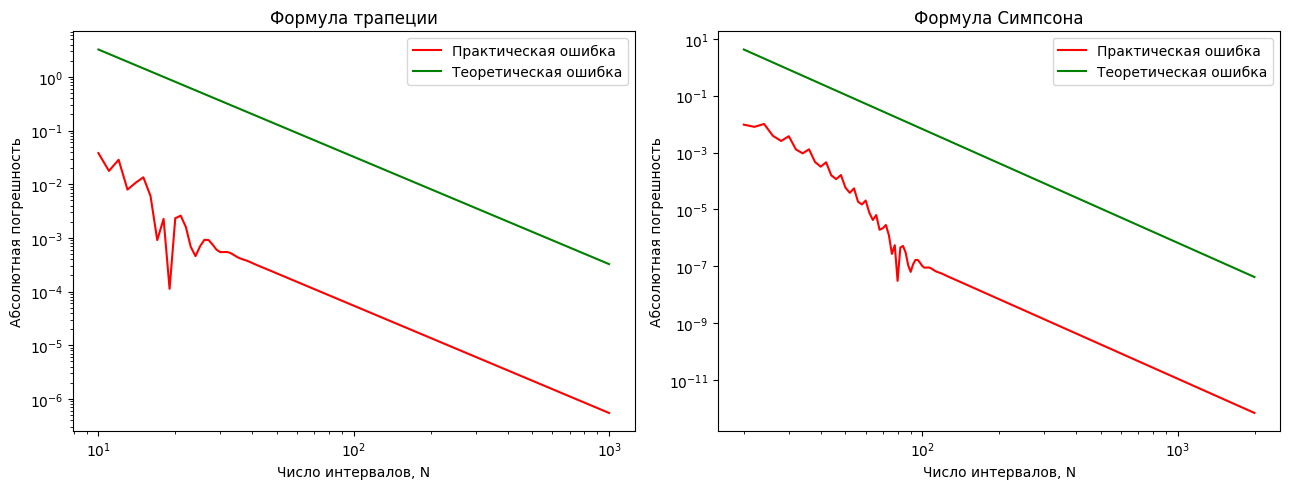

In [6]:
I = (np.arctan(15)+np.arctan(3))/3


def f(x):
    return 1/(1+9*x*x)


def get_I_by_trapez(f, N, a=-1, b=5):
    h = (b-a)/N
    f0 = [f(a + n*h) for n in range(1, N)]
    return h*(0.5*f(a) + np.sum(f0)+ 0.5*f(b))

def get_teor_err_trapez(N):
    return 324/np.power(N,2)


def get_I_by_simps(f, N, a=-1, b=5):
    h = (b-a)/N
    f0 = [f(a + n*h) for n in range(1, N)]
    return (h/3)*(f(a) + 4*np.sum(f0[0::2]) + 2*np.sum(f0[1::2]) + f(b))

def get_teor_err_simons(N):
    return 41990/np.power(N,4)


Ns = np.arange(10, 1000)
errs_tr = np.empty(Ns.shape)
errs_tr_teor = np.empty(Ns.shape)

errs_s = np.empty(Ns.shape)
errs_s_teor = np.empty(Ns.shape)


for i in range(Ns.shape[0]):
    errs_tr[i] = lf.get_abs_err(get_I_by_trapez(f, Ns[i]), I)
    errs_tr_teor[i] = get_teor_err_trapez(Ns[i])

    errs_s[i] = lf.get_abs_err(get_I_by_simps(f, 2 * Ns[i]), I)
    errs_s_teor[i] = get_teor_err_simons(Ns[i])


fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(Ns, errs_tr, 'r', label='Практическая ошибка')
ax[0].loglog(Ns, errs_tr_teor, 'g', label='Теоретическая ошибка')
ax[0].set_xlabel('Число интервалов, N')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].set_title('Формула трапеции')
ax[0].legend()

ax[1].loglog(Ns*2, errs_s, 'r', label='Практическая ошибка')
ax[1].loglog(Ns*2, errs_s_teor, 'g', label='Теоретическая ошибка')
ax[1].set_xlabel('Число интервалов, N')
ax[1].set_ylabel('Абсолютная погрешность')
ax[1].set_title('Формула Симпсона')
ax[1].legend()

fig.tight_layout()

#### 3.
##### 3.1 Правило Рунге:
Метод имеет порядок $p$, его ошибка имеет вид:
$$R(h)=C \cdot h^p+o(h^p)$$
Тогда:
$$I - I_h = C \cdot h^p$$
$$I - I_{h/2} = C \cdot (h/2)^p$$
Отсюдаполучаем формулу для оценки абсолютной ошибки:
$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{2^p - 1} $$

Для интегрирования через трапецию получаем ($p = 2$):

$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{3} $$


##### 3.2 Реализация для трапеции:
Реализуем чтобы поллучить абсолютную погрешность $10^{-6}$

Искомая точность достигается при числе шагов 1024 и 256 и шаге 5.859375e-03 и 2.343750e-02 соответственно для формулы трапеции и Симпсона


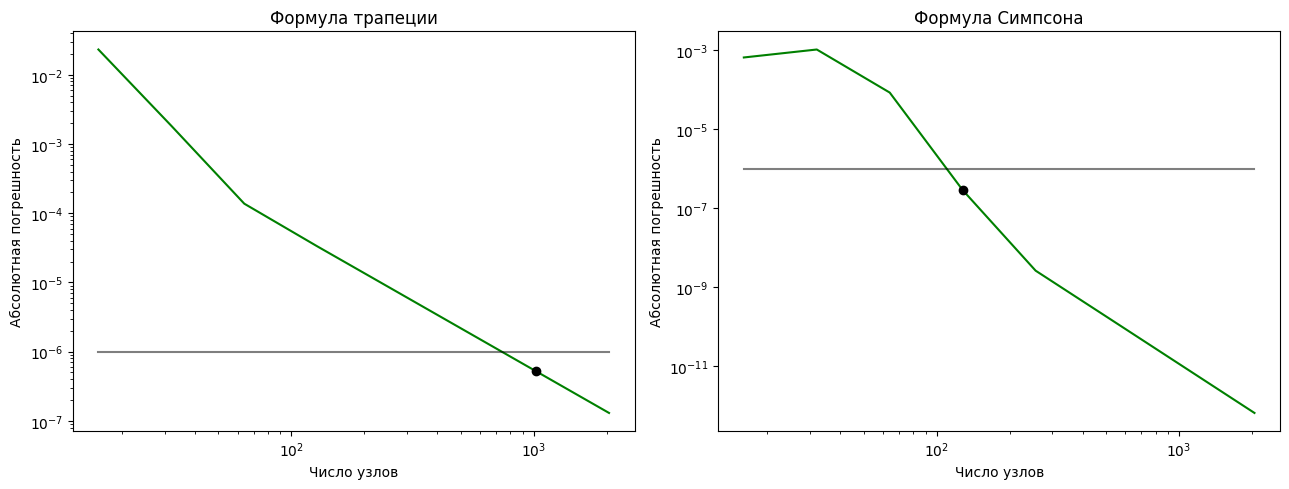

In [16]:
prec = 10**(-6)

runge_n = 2**np.arange(3, 12)
runge_err_t = np.empty(runge_n.shape[0])
runge_err_s = np.empty(runge_n.shape[0])
r_t, r_s = 0, 0

for i in range(1, runge_n.shape[0]):
    runge_err_t[i] = lf.get_abs_err(get_I_by_trapez(f, runge_n[i]), get_I_by_trapez(f, runge_n[i-1]))/3
    runge_err_s[i] = lf.get_abs_err(get_I_by_simps(f, runge_n[i]), get_I_by_simps(f, runge_n[i-1]))/15

    if (runge_err_t[i] < prec) and (runge_err_t[i-1] > prec):
        r_t = i
    if (runge_err_s[i] < prec) and (runge_err_s[i-1] > prec):
        r_s = i

print(f'Искомая точность достигается при числе шагов {runge_n[r_t]} и {2*runge_n[r_s]} и шаге {6/runge_n[r_t]:e} и {3/runge_n[r_s]:e} соответственно для формулы трапеции и Симпсона')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(runge_n[1:], runge_err_t[1:], 'g')
ax[0].loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax[0].loglog(runge_n[r_t], runge_err_t[r_t], 'o', mfc='k', mec='k')
ax[0].set_xlabel('Число узлов')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].set_title('Формула трапеции')

ax[1].loglog(runge_n[1:], runge_err_s[1:], 'g')
ax[1].loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax[1].loglog(runge_n[r_s], runge_err_s[r_s], 'o', mfc='k', mec='k')
ax[1].set_xlabel('Число узлов')
ax[1].set_ylabel('Абсолютная погрешность')
ax[1].set_title('Формула Симпсона')

fig.tight_layout()

#### 4.
##### 4.1 Правило Рунге для Симпсона:

Для интегрирования через Симпсона получаем ($p = 4$):

$$ I - I_{h/2} \approx \frac{I_{h/2} - I_h}{15} $$


##### 4.2 Реализация для Симпсона:
Реализуем чтобы поллучить абсолютную погрешность $10^{-6}$

In [ ]:
prec = 10**(-6)

runge_n = 2**np.arange(3, 12)
runge_err_t = np.empty(runge_n.shape[0])
runge_err_s = np.empty(runge_n.shape[0])
r_t, r_s = 0, 0

for i in range(1, runge_n.shape[0]):
    runge_err_t[i] = lf.get_abs_err(get_I_by_trapez(f, runge_n[i]), get_I_by_trapez(f, runge_n[i-1]))/3
    runge_err_s[i] = lf.get_abs_err(get_I_by_simps(f, runge_n[i]), get_I_by_simps(f, runge_n[i-1]))/15

    if (runge_err_t[i] < prec) and (runge_err_t[i-1] > prec):
        r_t = i
    if (runge_err_s[i] < prec) and (runge_err_s[i-1] > prec):
        r_s = i

print(f'Искомая точность достигается при числе шагов {runge_n[r_t]} и {2*runge_n[r_s]} и шаге {6/runge_n[r_t]:e} и {3/runge_n[r_s]:e} соответственно для формулы трапеции и Симпсона')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(runge_n[1:], runge_err_t[1:], 'g')
ax[0].loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax[0].loglog(runge_n[r_t], runge_err_t[r_t], 'o', mfc='k', mec='k')
ax[0].set_xlabel('Число узлов')
ax[0].set_ylabel('Абсолютная погрешность')
ax[0].set_title('Формула трапеции')

ax[1].loglog(runge_n[1:], runge_err_s[1:], 'g')
ax[1].loglog(runge_n[1:], prec*np.ones(runge_n.shape[0])[1:], 'k', alpha=0.5)
ax[1].loglog(runge_n[r_s], runge_err_s[r_s], 'o', mfc='k', mec='k')
ax[1].set_xlabel('Число узлов')
ax[1].set_ylabel('Абсолютная погрешность')
ax[1].set_title('Формула Симпсона')

fig.tight_layout()

#### 5.
##### 5.1 Веса формулы Ньютона-Котеса с равноотстоящими узлами:

Квадратурная формула Ньютона–Котеса ($w_i - веса$):

$$ \int_{-1}^{1} f(x) dx \approx \sum_{i = 0}^n w_i f(x_i) $$
$$ l_i(x) = \prod_{j \not i} \frac{x - x_j}{x_i - x_j} $$
$$ w_i = \int_{-1}^{1} l_i(x) dx $$


##### 5.2 Реализация для Симпсона:
Реализуем чтобы поллучить абсолютную погрешность $10^{-6}$

In [1]:
# проверка нормировки весов
import numpy.testing as npt
def newton_cotes(xk, a=-1, b=1):
    """Возвращает вектор весов `wk` квадратурной формулы для интервала [`a`,`b`]
    с узлами интегрирования в точках `xk`."""
    xk=np.asarray(xk)
    N = np.arange(len(xk), dtype=np.float32) # Массив степеней.
    W = xk[None,:]**N[:,None] # Матрица Вандермонда.
    L = np.linalg.inv(W) # Матрица перехода к базису из многочленов Лагранжа с узлами xk.
    N = N + 1 # Степени после интегрирования
    ix = (b**N-a**N)/N # Интегралы от одночленов.
    w = L@ix # Искомые веса.
    return w

Ns = np.arange(3, 50)
a = -1
b = 1
eps = 10**(-6)
i_c = 0
sums = np.empty(Ns.shape[0])
for i in range(1, Ns.shape[0]):
    sums[i] = np.abs(np.sum(newton_cotes(np.linspace(a, b, Ns[i])))-(b-a))/2

plt.semilogy(Ns, sums, 'g', label='Погрешность суммы весов')
plt.semilogy(Ns, eps*np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Допустимая погрешность')
plt.xlabel('Число узлов')
plt.ylabel('Относительная погрешность')
plt.legend()
plt.show()

# проверка симметричности весов
sims = np.empty(Ns.shape[0])
mask = np.full(Ns.shape[0], False)
for j in range(Ns.shape[0]):
    ws = newton_cotes(np.linspace(a, b, Ns[j]))
    sims[j] = np.max([np.abs(ws[i-1] - ws[-i])/ws[-i] for i in range(1, 1 + ws.shape[0] // 2)])
    if any(ws < 0):
        mask[j] = True


plt.semilogy(Ns, sims, 'g', label='Погрешность симметричных весов')
plt.semilogy(Ns, eps*np.ones(Ns.shape[0]), 'k', alpha=0.5, label='Допустимая погрешность')
plt.xlabel('Число узлов')
plt.ylabel('Относительная погрешность')
plt.legend()
plt.show()

print(f'Отрицательные веса появляются для числа узлов', Ns[mask])

NameError: name 'np' is not defined